In [2]:
import sys
import os
sys.path.append(os.path.abspath('..'))

import torch
import numpy as np

from dataset.dataset import Dataset
from utils.config import load_config
from utils.builder import build_trainer

# ResNet

In [3]:
config_path = "../configs/resnet_full.yaml"

In [4]:
config = load_config(config_path)
data_path = "../"+config["data"]["data_path"]

torch.manual_seed(config["experiment"]["seed"])
np.random.seed(config["experiment"]["seed"])

dataset = Dataset(data_path, "G", config["data"]["batch_size"], use_tabular=config["data"]["use_tabular"], tabular_features=config["data"]["tabular_features"])
train_loader, val_loader, test_loader = dataset.get_loaders()

dataset_f = Dataset(data_path, "F", config["data"]["batch_size"])
_, val_loader_f, test_loader_f = dataset_f.get_loaders()

dataset_m = Dataset(data_path, "M", config["data"]["batch_size"])       
_, val_loader_m, test_loader_m = dataset_m.get_loaders()

In [5]:
trainer = build_trainer(config)
trainer.load_checkpoint()

## Testing with simillar threshold

In [6]:
best_thr = trainer.choose_threshold(val_loader)

/home/maryna/anaconda3/envs/compmed/lib/python3.9/site-packages/torch/nn/modules/conv.py:366: UserWarning: Using padding='same' with even kernel lengths and odd dilation may require a zero-padded copy of the input be created (Triggered internally at /pytorch/aten/src/ATen/native/Convolution.cpp:1027.)
  return F.conv1d(


Best threshold: 0.513
Sensitivity: 0.913
Specificity: 0.850
AUC: 0.957
Accuracy: 0.880


In [7]:
print("\n===== ALL =====")
out = trainer.test(test_loader, best_thr)


===== ALL =====
           TEST RESULTS
  Threshold         : 0.513
  AUC               : 0.9606
  Accuracy          : 0.8764
  Sensitivity       : 0.9282  (recall on MI)
  Specificity       : 0.8192  (recall on NORM)
  Precision         : 0.8501
  F1 Score          : 0.8874
  Confusion Matrix
               Pred NORM   Pred MI
  True NORM  :     589        130
  True MI    :      57        737
              precision    recall  f1-score   support

        NORM       0.91      0.82      0.86       719
          MI       0.85      0.93      0.89       794

    accuracy                           0.88      1513
   macro avg       0.88      0.87      0.88      1513
weighted avg       0.88      0.88      0.88      1513



In [8]:
print("\n===== FEMALE =====")
out = trainer.test(test_loader_f, best_thr)


===== FEMALE =====
           TEST RESULTS
  Threshold         : 0.513
  AUC               : 0.9515
  Accuracy          : 0.8629
  Sensitivity       : 0.9046  (recall on MI)
  Specificity       : 0.8220  (recall on NORM)
  Precision         : 0.8324
  F1 Score          : 0.8670
  Confusion Matrix
               Pred NORM   Pred MI
  True NORM  :     291         63
  True MI    :      33        313
              precision    recall  f1-score   support

        NORM       0.90      0.82      0.86       354
          MI       0.83      0.90      0.87       346

    accuracy                           0.86       700
   macro avg       0.87      0.86      0.86       700
weighted avg       0.87      0.86      0.86       700



In [9]:
print("\n===== MALE =====")
out = trainer.test(test_loader_m, best_thr)


===== MALE =====
           TEST RESULTS
  Threshold         : 0.513
  AUC               : 0.9736
  Accuracy          : 0.8844
  Sensitivity       : 0.9485  (recall on MI)
  Specificity       : 0.8198  (recall on NORM)
  Precision         : 0.8413
  F1 Score          : 0.8917
  Confusion Matrix
               Pred NORM   Pred MI
  True NORM  :     332         73
  True MI    :      21        387
              precision    recall  f1-score   support

        NORM       0.94      0.82      0.88       405
          MI       0.84      0.95      0.89       408

    accuracy                           0.88       813
   macro avg       0.89      0.88      0.88       813
weighted avg       0.89      0.88      0.88       813



## Choosing best threshold separately for G, M and F

In [10]:
best_thr = trainer.choose_threshold(val_loader)

print("\n===== ALL =====")
out = trainer.test(test_loader, best_thr)

Best threshold: 0.513
Sensitivity: 0.921
Specificity: 0.853
AUC: 0.959
Accuracy: 0.886

===== ALL =====
           TEST RESULTS
  Threshold         : 0.513
  AUC               : 0.9567
  Accuracy          : 0.8691
  Sensitivity       : 0.9227  (recall on MI)
  Specificity       : 0.8183  (recall on NORM)
  Precision         : 0.8283
  F1 Score          : 0.8729
  Confusion Matrix
               Pred NORM   Pred MI
  True NORM  :     635        141
  True MI    :      57        680
              precision    recall  f1-score   support

        NORM       0.92      0.82      0.87       776
          MI       0.83      0.92      0.87       737

    accuracy                           0.87      1513
   macro avg       0.87      0.87      0.87      1513
weighted avg       0.87      0.87      0.87      1513



In [11]:
best_thr = trainer.choose_threshold(val_loader_f)

print("\n===== FEMALE =====")
out = trainer.test(test_loader_f, best_thr)

Best threshold: 0.494
Sensitivity: 0.916
Specificity: 0.816
AUC: 0.950
Accuracy: 0.860

===== FEMALE =====
           TEST RESULTS
  Threshold         : 0.494
  AUC               : 0.9407
  Accuracy          : 0.8500
  Sensitivity       : 0.8879  (recall on MI)
  Specificity       : 0.8144  (recall on NORM)
  Precision         : 0.8179
  F1 Score          : 0.8515
  Confusion Matrix
               Pred NORM   Pred MI
  True NORM  :     294         67
  True MI    :      38        301
              precision    recall  f1-score   support

        NORM       0.89      0.81      0.85       361
          MI       0.82      0.89      0.85       339

    accuracy                           0.85       700
   macro avg       0.85      0.85      0.85       700
weighted avg       0.85      0.85      0.85       700



In [12]:
best_thr = trainer.choose_threshold(val_loader_m)

print("\n===== MALE =====")
out = trainer.test(test_loader_m, best_thr)

Best threshold: 0.415
Sensitivity: 0.964
Specificity: 0.815
AUC: 0.961
Accuracy: 0.888

===== MALE =====
           TEST RESULTS
  Threshold         : 0.415
  AUC               : 0.9694
  Accuracy          : 0.8954
  Sensitivity       : 0.9806  (recall on MI)
  Specificity       : 0.8080  (recall on NORM)
  Precision         : 0.8399
  F1 Score          : 0.9048
  Confusion Matrix
               Pred NORM   Pred MI
  True NORM  :     324         77
  True MI    :       8        404
              precision    recall  f1-score   support

        NORM       0.98      0.81      0.88       401
          MI       0.84      0.98      0.90       412

    accuracy                           0.90       813
   macro avg       0.91      0.89      0.89       813
weighted avg       0.91      0.90      0.89       813



### ROC curves

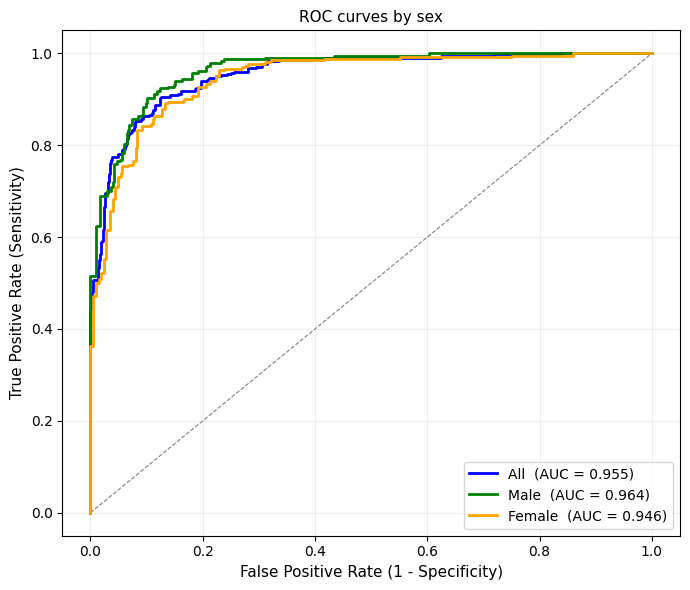

In [ ]:
from utils.metrics import plot_roc_curves

plot_roc_curves(
    trainer,
    loaders_dict={
        'All':    test_loader,
        'Male':   test_loader_m,
        'Female': test_loader_f,
    }
)